In [1]:
import numpy as np
import tqdm as tqdm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from numba import jit

In [2]:
MU_0 = 4e-7 * np.pi # магнитная постоянная
EPS_0 = 8.8541878188e-12 # электрическая постоянная
ETA_0 = np.sqrt(MU_0/EPS_0) # волновое сопротивление свободного пространства
C = 1/np.sqrt(MU_0*EPS_0) # скорость света в вакууме

In [12]:
nlamb = 50 # количество точек на одну длину волны
f = 100e6 # частота
lamb = C/f # длина волны
t = 1/f # период
dx = lamb/nlamb # шаг вдоль оси x
dy = lamb/nlamb # шаг вдоль оси y
dz = lamb/nlamb # шаг вдоль оси z
dt = dx/C/np.sqrt(3) # шаг по времени
N_lamb = 5 # количество длин волн в расчетной области
N_t = 5 # количество периодов для моделирования
nx = int(N_lamb*nlamb) # количество точек вдоль оси x
ny = int(N_lamb*nlamb) # количество точек вдоль оси y
nz = int(N_lamb*nlamb) # количество точек вдоль оси z
nt = int(N_t*t/dt) # количество временных шагов
print(f"Шаг по времени: {dt:.2e} с, количество временных шагов: {nt}")

Шаг по времени: 1.15e-10 с, количество временных шагов: 433


In [13]:
# def tr(a, dx, dy, dz): #a - массив с нулями по краям
#     """ Сдвиг индексов массива a на dx, dy, dz = +1, 0 или -1 """
#     mx = a.shape[0] #количество точек вдоль x с учетом крайних слоев
#     my = a.shape[1] 
#     mz = a.shape[2]
#     return a[1+dx:mx-1+dx, 1+dy:my-1+dy, 1+dz:mz-1+dz]
def s(dx, dy, dz):
    """ Сдвиг индексов на dx, dy, dz = +1, 0 или -1 для массивов без нулей по краям """
    end = lambda d: None if d == 0 else d
    return slice(1+dx, end(-1+dx)), slice(1+dy, end(-1+dy)), slice(1+dz, end(-1+dz))

In [14]:
# Крайние слои массивов заполнены нулями для реализации сдвига по индексам
Ex = np.zeros((nx+2, ny+2, nz+2))
Ey = np.zeros((nx+2, ny+2, nz+2))
Ez = np.zeros((nx+2, ny+2, nz+2))
Hx = np.zeros((nx+2, ny+2, nz+2))
Hy = np.zeros((nx+2, ny+2, nz+2))
Hz = np.zeros((nx+2, ny+2, nz+2))
sigm = np.zeros((nx+2, ny+2, nz+2))
mu = np.ones((nx+2, ny+2, nz+2))*MU_0
eps = np.ones((nx+2, ny+2, nz+2))*EPS_0

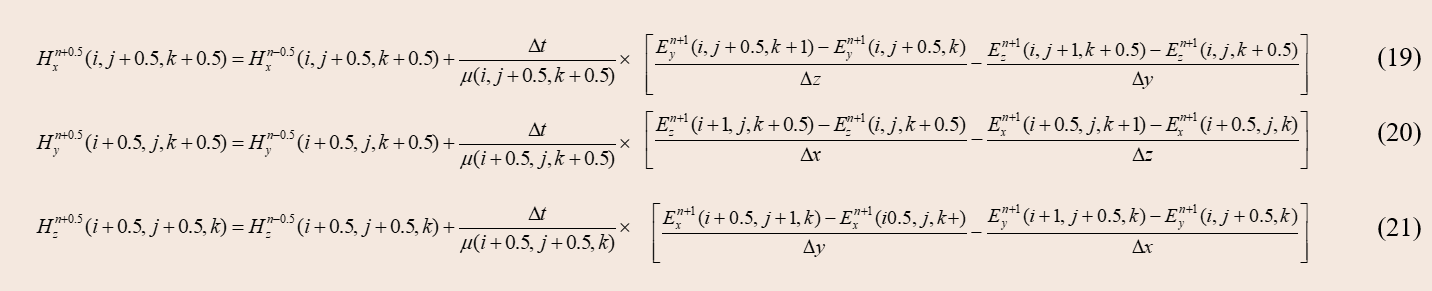

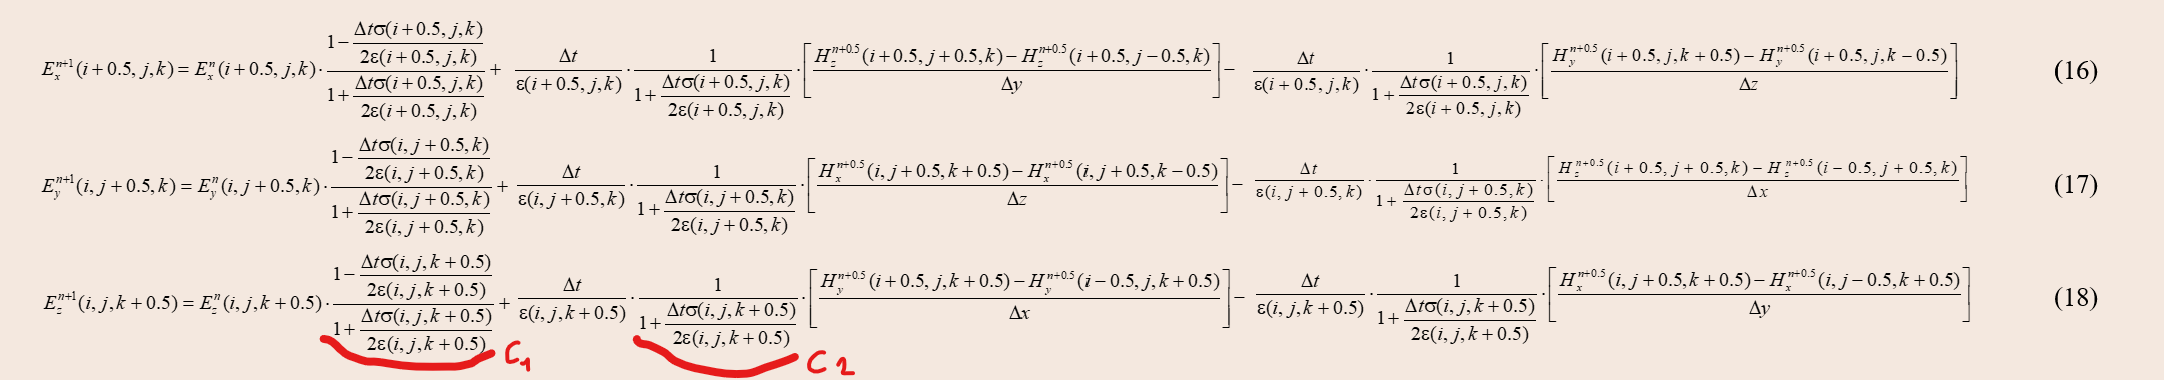

In [15]:
c_1 = (1 - sigm[s(0,0,0)]*dt/(2*eps[s(0,0,0)])) / (1 + sigm[s(0,0,0)]*dt/(2*eps[s(0,0,0)]))
c_2 = 1/(1 + sigm[s(0,0,0)]*dt/(2*eps[s(0,0,0)]))

In [16]:
# массив результатов для визуализации
Ez_time = np.zeros((nt, nx, ny))
print(np.shape(Hx[1:-1, 1:-1, 1:-1]))
print(np.shape(Hy[s(0,0,1)]))

(250, 250, 250)
(250, 250, 250)


In [11]:
# for i_t in tqdm.tqdm(range(nt)):
#     # обновление магнитного поля
#     Hx[s(0,0,0)] = Hx[s(0,0,0)] + dt/mu[s(0,0,0)]/2 * ((Ey[s(0,0,1)]-Ey[s(0,0,-1)])/dz - (Ez[s(0,1,0)]-Ez[s(0,-1,0)])/dy)
#     Hy[s(0,0,0)] = Hy[s(0,0,0)] + dt/mu[s(0,0,0)]/2 * ((Ez[s(1,0,0)]-Ez[s(-1,0,0)])/dx - (Ex[s(0,0,1)]-Ex[s(0,0,-1)])/dz)
#     Hz[s(0,0,0)] = Hz[s(0,0,0)] + dt/mu[s(0,0,0)]/2 * ((Ex[s(0,1,0)]-Ex[s(0,-1,0)])/dy - (Ey[s(1,0,0)]-Ey[s(-1,0,0)])/dx)
#     # обновление электрического поля
#     Ex[s(0,0,0)] = c_1*Ex[s(0,0,0)] - dt/eps[s(0,0,0)]*c_2/2 * ((Hy[s(0,0,1)]-Hy[s(0,0,-1)])/dz - (Hz[s(0,1,0)]-Hz[s(0,-1,0)])/dy)
#     Ey[s(0,0,0)] = c_1*Ey[s(0,0,0)] - dt/eps[s(0,0,0)]*c_2/2 * ((Hz[s(1,0,0)]-Hz[s(-1,0,0)])/dx - (Hx[s(0,0,1)]-Hx[s(0,0,-1)])/dz)
#     Ez[s(0,0,0)] = c_1*Ez[s(0,0,0)] - dt/eps[s(0,0,0)]*c_2/2 * ((Hx[s(0,1,0)]-Hx[s(0,-1,0)])/dy - (Hy[s(1,0,0)]-Hy[s(-1,0,0)])/dx)
#     Ez[nx//2+1, ny//2+1, nz//2+1] = 1.0 * np.sin(2*np.pi*f*dt*i_t) # источник в центре расчетной области
#     Ez_time[i_t] = Ez[1:-1, 1:-1, nz//2+1] # сохраняем сечение Ez для визуализации

In [17]:
#вариант без функции np.slice, для работы с numba
c_1 = (1 - sigm[1:-1, 1:-1, 1:-1]*dt/(2*eps[1:-1, 1:-1, 1:-1])) / (1 + sigm[1:-1, 1:-1, 1:-1]*dt/(2*eps[1:-1, 1:-1, 1:-1]))
c_2 = 1/(1 + sigm[1:-1, 1:-1, 1:-1]*dt/(2*eps[1:-1, 1:-1, 1:-1]))
@jit(parallel=True)
def TD_solver(Ex, Ey, Ez, Hx, Hy, Hz, mu, eps):
    # обновление магнитного поля
    Hx[1:-1, 1:-1, 1:-1] = Hx[1:-1, 1:-1, 1:-1] + dt/mu[1:-1, 1:-1, 1:-1]/2 * ((Ey[1:-1, 1:-1, 2:] - Ey[1:-1, 1:-1, :-2])/dz - (Ez[1:-1, 2:, 1:-1] - Ez[1:-1, :-2, 1:-1])/dy)
    Hy[1:-1, 1:-1, 1:-1] = Hy[1:-1, 1:-1, 1:-1] + dt/mu[1:-1, 1:-1, 1:-1]/2 * ((Ez[2:, 1:-1, 1:-1] - Ez[:-2, 1:-1, 1:-1])/dx - (Ex[1:-1, 1:-1, 2:] - Ex[1:-1, 1:-1, :-2])/dz)
    Hz[1:-1, 1:-1, 1:-1] = Hz[1:-1, 1:-1, 1:-1] + dt/mu[1:-1, 1:-1, 1:-1]/2 * ((Ex[1:-1, 2:, 1:-1] - Ex[1:-1, :-2, 1:-1])/dy - (Ey[2:, 1:-1, 1:-1] - Ey[:-2, 1:-1, 1:-1])/dx)
    # обновление электрического поля
    Ex[1:-1, 1:-1, 1:-1] = c_1*Ex[1:-1, 1:-1, 1:-1] - dt/eps[1:-1, 1:-1, 1:-1]*c_2/2 * ((Hy[1:-1, 1:-1, 2:] - Hy[1:-1, 1:-1, :-2])/dz - (Hz[1:-1, 2:, 1:-1] - Hz[1:-1, :-2, 1:-1])/dy)
    Ey[1:-1, 1:-1, 1:-1] = c_1*Ey[1:-1, 1:-1, 1:-1] - dt/eps[1:-1, 1:-1, 1:-1]*c_2/2 * ((Hz[2:, 1:-1, 1:-1] - Hz[:-2, 1:-1, 1:-1])/dx - (Hx[1:-1, 1:-1, 2:] - Hx[1:-1, 1:-1, :-2])/dz)
    Ez[1:-1, 1:-1, 1:-1] = c_1*Ez[1:-1, 1:-1, 1:-1] - dt/eps[1:-1, 1:-1, 1:-1]*c_2/2 * ((Hx[1:-1, 2:, 1:-1] - Hx[1:-1, :-2, 1:-1])/dy - (Hy[2:, 1:-1, 1:-1] - Hy[:-2, 1:-1, 1:-1])/dx)
    Ez_time = Ez[1:-1, 1:-1, nz//2+1] # сохраняем сечение Ez для визуализации
    return Ez_time

In [18]:
for i_t in tqdm.tqdm(range(nt)):
    Ez_time[i_t] = TD_solver(Ex, Ey, Ez, Hx, Hy, Hz, mu, eps)
    Ez[nx//2+1, ny//2+1, nz//2+1] = 1.0 * np.sin(2*np.pi*f*dt*i_t) # источник в центре расчетной области

100%|██████████| 433/433 [02:53<00:00,  2.50it/s]


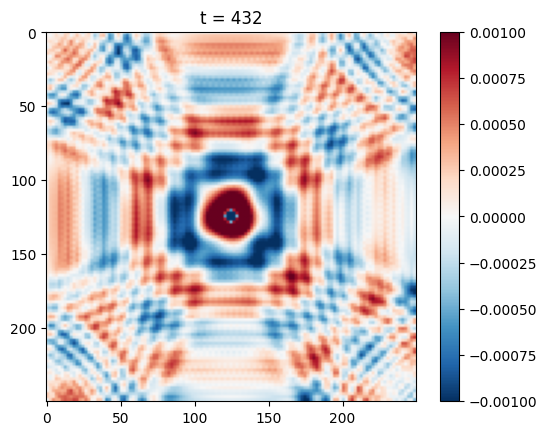

In [21]:
fig, ax = plt.subplots()
im = ax.imshow(Ez_time[0], cmap='RdBu_r', vmin=-0.001, vmax=0.001)
plt.colorbar(im)

def update(frame):
    im.set_data(Ez_time[frame][1::2, 1::2]) # отображаем каждый второй пиксель для ускорения анимации
    ax.set_title(f"t = {frame}")
    return (im,)

ani = FuncAnimation(fig, update, frames=nt, interval=50, blit=True)

ani.save("heatmap.gif", writer="pillow", fps=20)

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

frames = []

x = np.linspace(0, 2*np.pi, 200)
y = np.linspace(0, 2*np.pi, 200)
X, Y = np.meshgrid(x, y)

for t in range(100):
    Z = np.sin(X + Y + t * 0.1)

    plt.imshow(Z, cmap="viridis", vmin=-1, vmax=1)
    plt.colorbar()
    plt.title(f"t={t}")
    
    plt.savefig("frame.png")
    frames.append(imageio.imread("frame.png"))
    plt.clf()

imageio.mimsave("heatmap.gif", frames, fps=20)

C:\Users\Michael\AppData\Local\Temp\ipykernel_8340\3015000722.py:19: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread("frame.png"))


<Figure size 640x480 with 0 Axes>

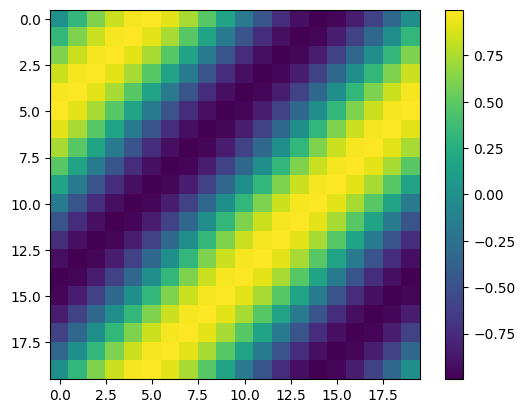

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
HTML(ani.to_jshtml())

# создаём сетку
x = np.linspace(0, 2*np.pi, 20)
y = np.linspace(0, 2*np.pi, 20)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots()
im = ax.imshow(np.sin(X + Y), cmap="viridis", animated=True)
plt.colorbar(im)

def update(frame):
    Z = np.sin(X + Y + frame * 0.1)
    im.set_array(Z)
    return [im]

ani = FuncAnimation(fig, update, frames=100, interval=1)

ani.save("heatmap.gif", writer="pillow", fps=1)